# Gradient Descent algorithms as a means to find Ackley Function's minimum

## Introduction

In this document, we shall implement the following algorightms to find the smallest possible values of the Ackley Function:
- Gradient Descent
- Gradient Descent With Momentum

## Ackley Function

First of all, to observe the properties of the Ackley function, we have to implement it in out program. I have decided to define a general method that can return a d-dimensional version of the desired callable, with customizable a, b and c constants. This ensures the program is reusable and universal. The normula for this function is as follows:
$$
f(\mathbf{x}) = -a \exp\left(-b \sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2}\right)
- \exp\left(\frac{1}{d} \sum_{i=1}^{d} \cos(c x_i)\right)
+ a + e
$$

It will be implemented in a more optimal way (using operations like np.linalg.norm, etc.) to provide the highest possible performance

In [148]:
import math
from typing import Callable
import numpy as np
import numpy.typing as npt

def ackley_function_generate(a: float, b: float, c: float, d: int) -> Callable[[npt.NDArray[np.float64]], float]:

    def ackley_function(x: npt.NDArray[np.float64]) -> float:
        # if len(x) != d:               # These lines were commented out to allow for vectorization of the function
        #     raise ValueError(f"Expected exactly {d} parameters")

        r = np.linalg.norm(x)
        s = np.mean(np.cos(x*c))

        return -a * math.exp(-b * math.sqrt(1/d)*r) - math.exp(s) + a + math.e

    return ackley_function

I will define 1- and 2-dimensional versions of the function with the given parameters, as those shall be the ones we are going to analyze. The vectorized version of the one-dimensional Ackley function is also helpful to define, as it allows us to write more concise and faster code further on.

In [149]:
ackley_one_dim = ackley_function_generate(20, 0.2, 2 * math.pi, d=1)
ackley_two_dim = ackley_function_generate(20, 0.2, 2 * math.pi, d=2)

ackley_one_dim_vectorized = np.vectorize(ackley_one_dim)

print(ackley_one_dim(np.array([20.31], dtype=np.float64)))
print(ackley_two_dim(np.array([20.31, 30.56], dtype=np.float64)))

21.68195973541175
22.084162833101548


Now we have to define the Ackley function's gradient. It can be calculated easily and it is defined like this:
$$
\nabla f(\mathbf{x}) =
\frac{ab}{\sqrt{d}} \frac{\mathbf{x}}{\|\mathbf{x}\|}
\exp\!\left(-\frac{b}{\sqrt{d}}\|\mathbf{x}\|\right)
+
\frac{c}{d}
\begin{bmatrix}
\sin(c x_1) \\
\vdots \\
\sin(c x_d)
\end{bmatrix}
\exp\!\left(\frac{1}{d}\sum_{j=1}^d \cos(c x_j)\right)
$$

In [150]:
def ackley_function_gradient(a: float, b: float, c: float, d: int) -> Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]]:
    def ackley_gradient(x: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        if len(x) != d:
            raise ValueError(f"Expected exactly {d} parameters")

        r = np.linalg.norm(x)
        s = np.mean(np.cos(c * x))

        if r == 0.0:
            return np.zeros(d, dtype=np.float64)

        return (
            (a * b / np.sqrt(d)) * (x / r) * np.exp(-b * r / np.sqrt(d))
            + (c / d) * np.sin(c * x) * np.exp(s)
        )

    return ackley_gradient

We need to create the instances representing our functions' gradients

In [151]:
ackley_one_dim_grad = ackley_function_gradient(20, 0.2, 2 * math.pi, d=1)
ackley_two_dim_grad = ackley_function_gradient(20, 0.2, 2 * math.pi, d=2)

print(ackley_one_dim_grad(np.array([20.31], dtype=np.float64)))
print(ackley_two_dim_grad(np.array([23.1, 59.3], dtype=np.float64)))

[4.11167412]
[2.37118469 3.83677765]


We can graph the Ackley function to be able to analyze it more thoroughly

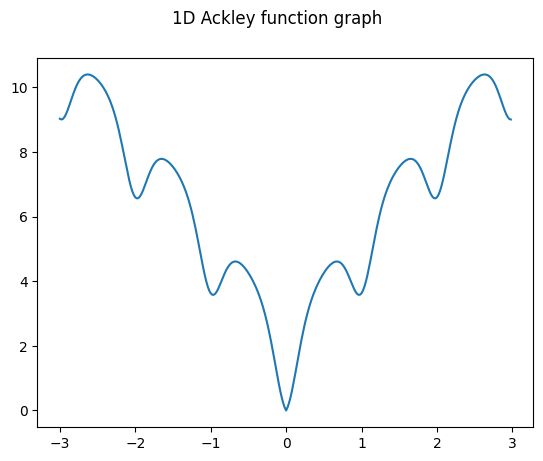

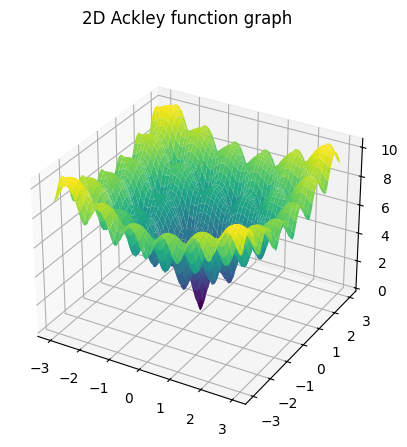

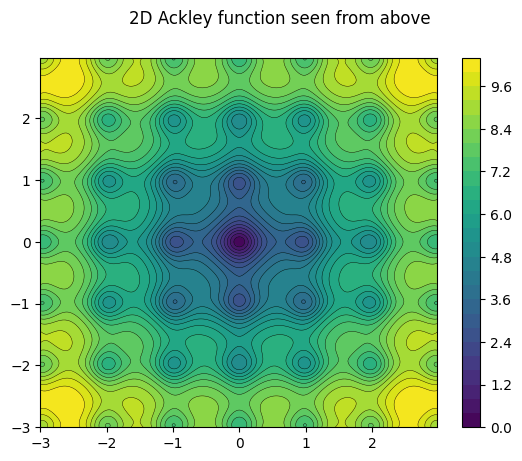

In [152]:
from matplotlib import pyplot as plt
import warnings

graphing_abs_bound = 2.5
graphing_abs_margin = .5

graphing_abs_frame = graphing_abs_bound + graphing_abs_margin

warnings.filterwarnings("ignore")
inputs_1d = np.arange(-graphing_abs_frame, graphing_abs_frame, 0.02, dtype=np.float64)

x_2d, y_2d = np.meshgrid(inputs_1d, inputs_1d)
inputs_2d = np.stack([x_2d.ravel(), y_2d.ravel()], axis=1)

outputs_1d = ackley_one_dim_vectorized(inputs_1d)
outputs_2d = np.apply_along_axis(ackley_two_dim, 1, inputs_2d)
z_2d = outputs_2d.reshape(x_2d.shape)

fig_1d, ax_1d = plt.subplots()
ax_1d.plot(inputs_1d, outputs_1d)
fig_1d.suptitle("1D Ackley function graph")

fig_2d_projection = plt.figure()
ax = fig_2d_projection.add_subplot(projection="3d")
ax.plot_surface(x_2d, y_2d, z_2d, cmap="viridis")
fig_2d_projection.suptitle("2D Ackley function graph")
plt.show()

fig_2d_colours, ax_2d_colours = plt.subplots()
contour = ax_2d_colours.contourf(x_2d, y_2d, z_2d, levels=30, cmap="viridis")
ax_2d_colours.contour(x_2d, y_2d, z_2d, levels=30, colors="black", linewidths=0.3)
fig_2d_colours.colorbar(contour, ax=ax_2d_colours)
fig_2d_colours.suptitle("2D Ackley function seen from above")
fig_2d_colours.show()

## Gradient Descent

Now lets implement the basic Gradient Descent algorithm. It's a simple function that uses gradient to find the direction of steepest descent towards the minimum and "moves" towards it. Its step length is decided by the learning_rate hyperparameter (represented by eta in the following formula). 

The core of the algorithm works in the following way:
$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \eta \, \nabla f(\mathbf{x}_k)
$$

I've modified it to be able to stop upon finding a spot, where gradient is almost 0 and I gave it the ability to save every step it does in an array, so that we can graph it later on.

In [153]:
def gradient_descent(
    start_pos: npt.NDArray[np.float64],
    learning_rate: float,
    iteration_amount: int,
    gradient_function: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]],
    save_interval: int,
    minimum_grad_norm: np.float64
    ) -> npt.NDArray[np.float64]:
    pos = start_pos.copy()
    pos_history: list[npt.NDArray[np.float64]] = [pos]
    for i in range(iteration_amount):
        grad = gradient_function(pos)
        if np.linalg.norm(grad) < minimum_grad_norm:
            break
        pos = pos - learning_rate * grad
        if not i % save_interval:
            pos_history.append(pos)
    pos_history.append(pos)
    return (pos, np.array(pos_history, dtype=np.float64))

Lets see if the gradient descent function is able to find the local minimum, and therefore, make the output smaller.
We will test both 1D and 2D versions of the Ackley function

In [154]:
from IPython.display import display
import copy

learning_rate_1d = 0.01
iterations_1d = 1_000
start_pos_1d = np.array([2.5], dtype=np.float64)
save_interval = 1
min_grad_norm = 1e-3

learning_rate_2d = 0.01
iterations_2d = 1_000
start_pos_2d = np.array([-1.35, -1.5], dtype=np.float64)
start_pos_2d_copy = copy.deepcopy(start_pos_2d)

after_descent_1d = gradient_descent(start_pos_1d, learning_rate_1d, iterations_1d, ackley_one_dim_grad, save_interval, min_grad_norm)
after_descent_2d = gradient_descent(start_pos_2d, learning_rate_2d, iterations_2d, ackley_two_dim_grad, save_interval, min_grad_norm)

y_start_1d = ackley_one_dim(start_pos_1d)
y_end_1d = ackley_one_dim(after_descent_1d[0])
y_start_2d = ackley_two_dim(start_pos_2d)
y_end_2d = ackley_two_dim(after_descent_2d[0])

print(f"""\
1D Ackley Function:
startPos: {start_pos_1d}
startY: {y_start_1d}

endPos: {after_descent_1d[0]}
endY: {y_end_1d}


==========================


2D Ackley Function:
startPos: {start_pos_2d}
startY: {y_start_2d}

endPos: {after_descent_2d[0]}
endY: {y_end_2d}
""")



1D Ackley Function:
startPos: [2.5]
startY: 10.219789193034934

endPos: [1.97445485]
endY: 6.559645376042507




2D Ackley Function:
startPos: [-1.35 -1.5 ]
startY: 7.231846839778623

endPos: [-0.96848424 -0.96848823]
endY: 3.5744518810883013



We can observe that our Gradient Descent function does find smaller y values, than what we started with. This is a good sign, it might mean that it works as expected.

Lets visualize the function's inputs and outputs that we calculated here. We'll be using graphs illustrating, which path specifically the gradient descent took to the point.

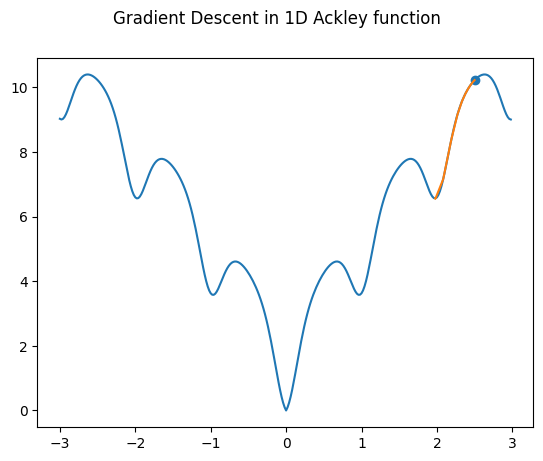

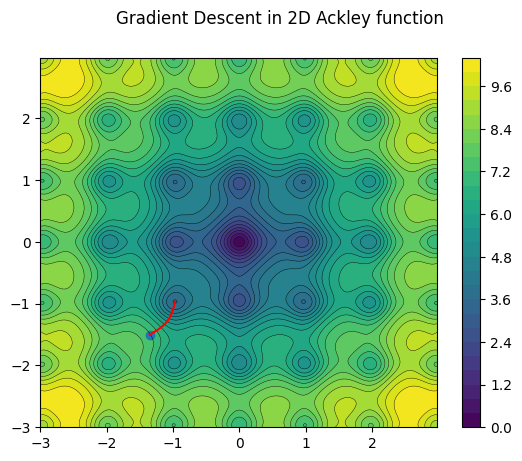

In [155]:
fig_1d_path = copy.deepcopy(fig_1d)
fig_2d_colours_path = copy.deepcopy(fig_2d_colours)

ax_1d_path = fig_1d_path.axes[0]
ax_2d_colours_path = fig_2d_colours_path.axes[0]

x_start_1d = start_pos_1d[0].item()

inputs_1d_path = after_descent_1d[1]
outputs_1d_path = ackley_one_dim_vectorized(inputs_1d_path)

ax_1d_path.plot(inputs_1d_path, outputs_1d_path)
ax_1d_path.scatter([x_start_1d], [y_start_1d])

fig_1d_path.suptitle("Gradient Descent in 1D Ackley function")
display(fig_1d_path)

start_pos_2d_tup = tuple(start_pos_2d)
ax_2d_colours_path.plot(*after_descent_2d[1].T, color="red")

ax_2d_colours_path.scatter([start_pos_2d_tup[0]], [start_pos_2d_tup[1]])
fig_2d_colours_path.suptitle("Gradient Descent in 2D Ackley function")
display(fig_2d_colours_path)

In both the 1D and 2D versions, GD found a coordinate very close to the nearest local minimum. This is exactly what we wanted. The "bent" path that arose in the 2D function is a common and acceptable outcome. There are methods to make the path shorter and more direct, but they can be more computationally demanding (for instance, computing the inverse of the Hessian) and not suited for our use case.

One of the most important hyperparameters of the algorithm is iteration amount - how long do we let Gradient Descent operate to find the correct solution. To see the difference between higher and lower values of this param, i will now make a similar simulation to the one above, but with a much lower iteration amount and I will compare the outcomes.

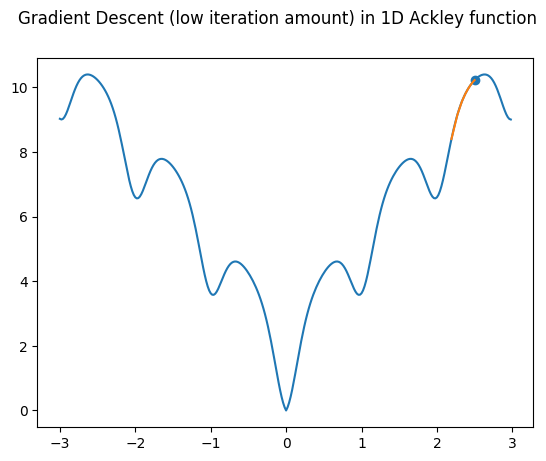

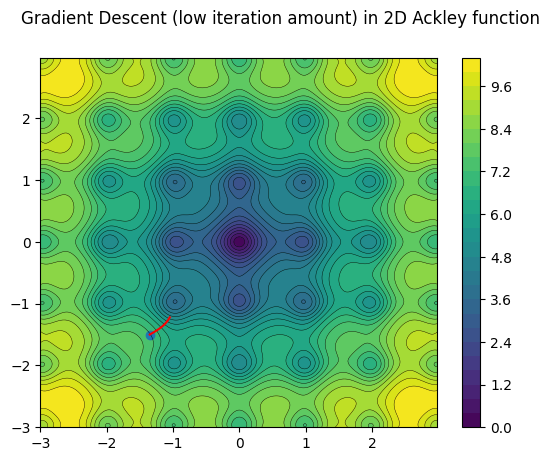

In [156]:
iterations_1d_low = 7
iterations_2d_low = 9

fig_1d_low = copy.deepcopy(fig_1d)
fig_2d_colours_low = copy.deepcopy(fig_2d_colours)

after_descent_1d_low = gradient_descent(start_pos_1d, learning_rate_1d, iterations_1d_low, ackley_one_dim_grad, save_interval, min_grad_norm)
after_descent_2d_low = gradient_descent(start_pos_2d, learning_rate_2d, iterations_2d_low, ackley_two_dim_grad, save_interval, min_grad_norm)

ax_1d_low = fig_1d_low.axes[0]
ax_2d_colours_low = fig_2d_colours_low.axes[0]

x_start_1d = start_pos_1d[0].item()

inputs_1d_path = after_descent_1d_low[1]
outputs_1d_path = ackley_one_dim_vectorized(inputs_1d_path)

ax_1d_low.plot(inputs_1d_path, outputs_1d_path)
ax_1d_low.scatter([x_start_1d], [y_start_1d])
fig_1d_low.suptitle("Gradient Descent (low iteration amount) in 1D Ackley function")
display(fig_1d_low)

start_pos_2d_tup = tuple(start_pos_2d)
ax_2d_colours_low.plot(*after_descent_2d_low[1].T, color="red")

ax_2d_colours_low.scatter([start_pos_2d_tup[0]], [start_pos_2d_tup[1]])
fig_2d_colours_low.suptitle("Gradient Descent (low iteration amount) in 2D Ackley function")
display(fig_2d_colours_low)

As we can see, a low iteration amount parameter can lead to the algorithm stopping before it can find the minimum, even though it was heading in the right direction.

Another very interesting parameter is learning_rate. it describes how quickly the algorithm goes towards a lower point. Too high - it can overshoot the minimum, too low - the descent may be too slow and it will get stuck in the closest local minimum.

We will test a set of several starting points with 4 different learning_rate values to test, how changing learning_rate can impact the result.

The results will be visualized using arrows that point from the starting point to the end point instead of the full path, as the graph would be completely unreadable otherwise.

In the case of an arrow pointing out of the considered area, it will not be rendered, so as to improve readability.  
When analyzing the graphs, have in mind the fact that in some examples, two arrows may overlap.

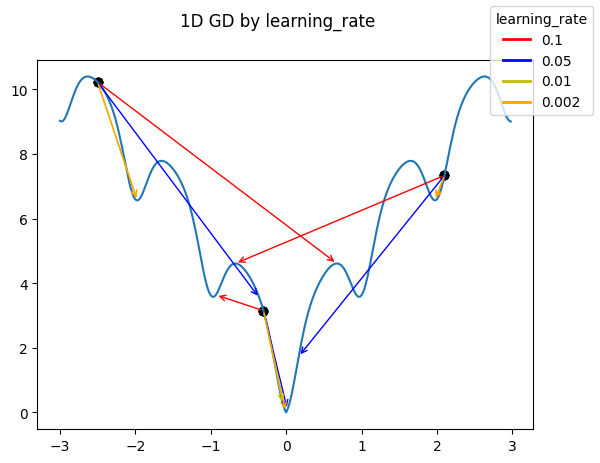

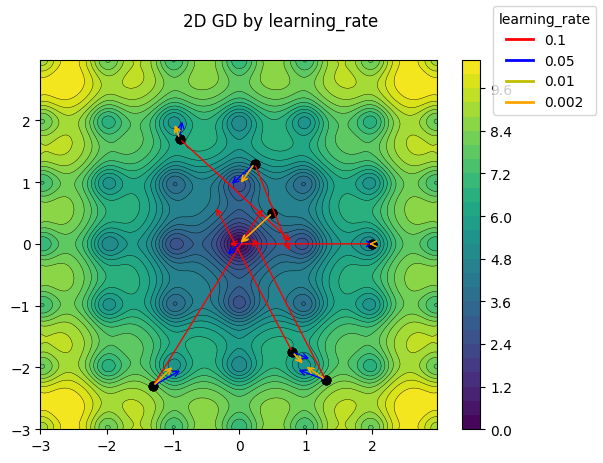

In [157]:
from typing import Any
from dataclasses import dataclass
from matplotlib.lines import Line2D
from matplotlib.axes import Axes
from matplotlib.figure import Figure

learning_rate_multiple = np.array([0.1, 0.05, 0.01, 0.002], dtype=np.float64)
colours = ["r", "b", "y", "orange"]
iterations_multiple = 10_000
# inputs_generated_1d = 5
# inputs_generated_2d = 25

learning_rate_colour_match = dict(zip(learning_rate_multiple, colours))

fig_1d_arrow_multiple = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple = fig_1d_arrow_multiple.axes[0]
ax_2d_colours_arrow_multiple = fig_2d_colours_arrow_multiple.axes[0]

inputs_1d_multiple = np.array([[-2.5],[2.1],[-0.3]], dtype=np.float64)
inputs_2d_multiple = np.array([[0.5, 0.5],[2, 0],[1.3, -2.2],[-0.9, 1.7],[0.23, 1.3],[-1.3, -2.3],[0.8, -1.75]], dtype=np.float64)

inputs_1d_reshaped = np.reshape(inputs_1d_multiple, (len(inputs_1d_multiple)))
outputs_1d_multiple = ackley_one_dim_vectorized(inputs_1d_reshaped)


@dataclass
class Arrow:
    start_x: np.float64
    start_y: np.float64
    end_x: np.float64
    end_y: np.float64
    metadata: dict[str, Any]


arrow_list_1d_multiple: list[Arrow] = []
arrow_list_2d_multiple: list[Arrow] = []
for learning_rate in learning_rate_multiple:
    for inp, outp in zip(inputs_1d_multiple, outputs_1d_multiple):
        # print(inp, outp)
        after_descent_1d_single = gradient_descent(inp, learning_rate, iterations_multiple, ackley_one_dim_grad, save_interval, min_grad_norm)
        arrow_list_1d_multiple.append(Arrow(
            inp[0],
            outp,
            after_descent_1d_single[0][0],
            np.float64(ackley_one_dim(after_descent_1d_single[0][0])),
            {
                "colour": learning_rate_colour_match[learning_rate],
                "learning_rate" : learning_rate
            }
        ))

    for inp in inputs_2d_multiple:
        after_descent_2d_single = gradient_descent(inp, learning_rate, iterations_multiple, ackley_two_dim_grad, save_interval, min_grad_norm)
        arrow_list_2d_multiple.append(Arrow(
            inp[0],
            inp[1],
            after_descent_2d_single[0][0],
            after_descent_2d_single[0][1],
            {
                "colour": learning_rate_colour_match[learning_rate],
                "learning_rate" : learning_rate
            }
        ))

# print(after_descent_1d_multiple)

def annotate_arrows(arrow_list: list[Arrow], axis: Axes) -> None:
    for arrow in arrow_list:
        # print(arrow)
        # print(round(ackley_two_dim(np.array([arrow.end_x, arrow.end_y])) * 1000)/1000.0)
        axis.annotate(
            "",
            xy=(arrow.end_x, arrow.end_y),
            xytext=(arrow.start_x, arrow.start_y),
            arrowprops=dict(arrowstyle="->", color=arrow.metadata["colour"])
        )

def seperate_starting_points(arrow_list: list[Arrow]) -> tuple[np.float64, np.float64]:
    points = np.array([(elem.start_x, elem.start_y) for elem in arrow_list])
    transposed = points.T
    return transposed[0], transposed[1]

def plot_gradient_descent(arrows: list[Arrow], ax: Axes, fig: Figure, title: str):
    annotate_arrows(arrows, ax)
    # print(arrows)
    sp = seperate_starting_points(arrows)
    # print(sp)
    ax.scatter(*sp, c="black")
    legend_elements = [
        Line2D([0], [0], color=color, lw=2, label=learning_rate)
        for learning_rate, color in learning_rate_colour_match.items()
    ]
    fig.legend(handles=legend_elements, title="learning_rate")
    fig.suptitle(title)
    display(fig)

plot_gradient_descent(arrow_list_1d_multiple, ax_1d_arrow_multiple, fig_1d_arrow_multiple, "1D GD by learning_rate")
plot_gradient_descent(arrow_list_2d_multiple, ax_2d_colours_arrow_multiple, fig_2d_colours_arrow_multiple, "2D GD by learning_rate")

1D Outcomes:
|   | 0.1   | 0.05  | 0.01  | 0.02  |
|---|-------|-------|-------|-------|
| 1 | 4.609 | 3.543 | 6.560 | 6.560 |
| 2 | 4.609 | 1.733 | 6.560 | 6.560 |
| 3 | 3.636 | 0.086 | 0.250 | 0.019 |

2D Outcomes:
|   | 0.1   | 0.05  | 0.01  | 0.002 |
|---|-------|-------|-------|-------|
| 1 | 0.085 | 2.193 | 0.064 | 0.009 |
| 2 | 1.235 | 4.993 | 4.884 | 4.884 |
| 3 | 1.624 | 5.839 | 5.382 | 5.382 |
| 4 | 2.928 | 5.839 | 5.382 | 5.382 |
| 5 | 3.373 | 3.062 | 2.580 | 2.58  |
| 6 | 4.146 | 5.839 | 5.382 | 5.382 |
| 7 | 4.160 | 5.837 | 5.382 | 5.382 |

We may notice that higher learning rate values can often lead us to other basins, and this is can be a double edged sword. In our case, it did usually lead them towards lower places (the big learning rate allowed them to "escape te hole"), however, in one example, it made our minimizing algorithm finish on a higher value than the starting one, which is a terrible outcome. Even if they get into a lower basin (positive effect), they do not accurately fall into the closest minimum, but rather oscillate along the hole's borders. This makes using higher learning rate in algorigthm much less predictable - which can cause both awesome and terrible results, often unexpectedly.

Lower learning rate values are safer - they always fall into the closest local minimum. This means they always improve our situation with basically no room for failure. Consequently, they are unfit for finding the global minimum, as they almost always get stuck in the basin they are in, with no chance of escaping, however they do excel at finding local minima.

Let's visualize, how the function performs on a high learning rate value to see exactly, why those paths were so different, seemingly random. This could shine some light on why sometimes it leads directly to the global minimum and in the other cases - it can make the point we find less optimal.

I will use the point from the first 2D function graphed, but with a much higher learning rate. Originally, we saw that it just travelled roughly along the desired path. This simulation will show its behaviour on a much bigger learning rate. 

The 1D function will not be visualized, as the 2D simulation provides much more useful data in this case.

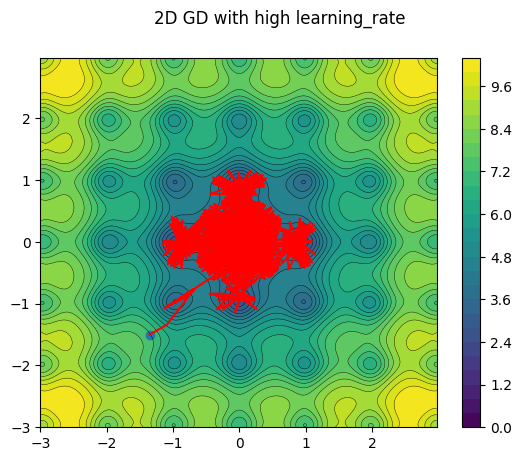

In [158]:
learning_rate_2d_high = .1
save_interval_high = 1

fig_2d_colours_path_high = copy.deepcopy(fig_2d_colours)
ax_2d_colours_path_high = fig_2d_colours_path_high.axes[0]

after_descent_2d_high = gradient_descent(start_pos_2d, learning_rate_2d_high, iterations_2d, ackley_two_dim_grad, save_interval_high, min_grad_norm)

ax_2d_colours_path_high.plot(*after_descent_2d_high[1].T, color="red")

ax_2d_colours_path_high.scatter([start_pos_2d_tup[0]], [start_pos_2d_tup[1]])
fig_2d_colours_path_high.suptitle("2D GD with high learning_rate")
display(fig_2d_colours_path_high)


This graph might look cluttered, but this tells us exactly, what we wanted to know. We can observe large jumps between the local minima and their neighbourhoods.

In the lower learning_rate version, we just slowly and controllably descended into the basin. In this case though, we just leap between them, uncontrollably and unreliably. Therefore, even though larger learning_rate values can lead to more optimal solutions, depending on a chance that we will just encounter a good solution almost randomly is very risky and can not be considered a reliable strategy.

As we see, this approach is not ideal. The global minimum can be often seemingly impossible to get to by only using the regular Gradient Descent. There are other algorithms that may perform better though. 

## Gradient Descent With Momentum

Gradient Descent With Momentum is a modified version of regular Gradient Descent. It implements a "momentum" mechanic, where travelling in a specific direction causes the point to gain speed along its velocity vector. It can sometimes cause more promising results than the basic GD algorithm.

The core of the function are the following operations:
$$
\begin{aligned}
\mathbf{v}_{k+1} &= \gamma \, \mathbf{v}_k + \eta \, \nabla f(\mathbf{x}_k) \\
\mathbf{x}_{k+1} &= \mathbf{x}_k - \mathbf{v}_{k+1}
\end{aligned}
$$

Where;
- $ \eta $ - learning rate
- $ \gamma $ - momentum coefficient

Let's define this function and check if it generates more accurate outputs.

In [159]:
def gradient_descent_with_momentum(
    start_pos: npt.NDArray[np.float64],
    learning_rate: float,
    momentum_coefficient: float,
    iteration_amount: int,
    gradient_function: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]],
    save_interval: int,
    minimum_grad_norm: np.float64
    ) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    pos = start_pos.copy()
    pos_history: list[npt.NDArray[np.float64]] = [pos]
    v = np.zeros_like(start_pos)
    for i in range(iteration_amount):
        grad = gradient_function(pos)
        if np.linalg.norm(grad) < minimum_grad_norm:
            break
        v = momentum_coefficient * v + learning_rate * gradient_function(pos)
        pos = pos - v
        if not i % save_interval:
            pos_history.append(pos)
    pos_history.append(pos)
    return (pos, np.array(pos_history, dtype=np.float64))

Now the first check if our GDWM can find a point that yields smaller output when used as the Ackley function's argument. I will be using the parameters from the first Gradient Descent (with the high iteration amount) to see if this GDWM changes anything in our outcome. In this case, both paths and arrows will be used to illustrate both how the descent evolved and the final movement of the point that it caused.

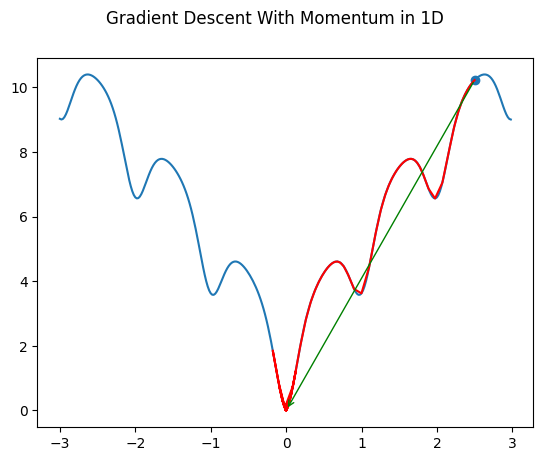

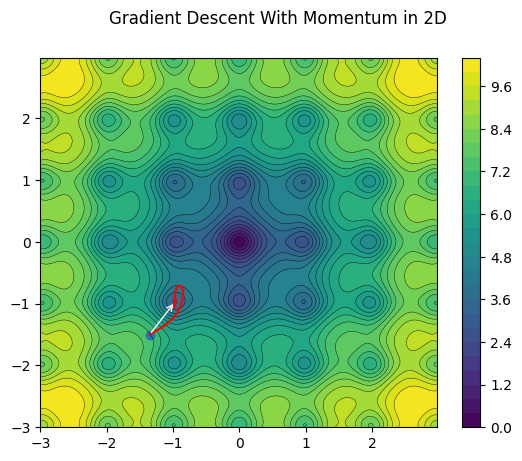

In [160]:
from IPython.display import display

momentum_coefficient = 0.9
save_interval_m = 1
iterations_1d_m = 1_000
iterations_2d_m = 1_000

after_descent_1d_m = gradient_descent_with_momentum(start_pos_1d, learning_rate, momentum_coefficient, iterations_1d_m, ackley_one_dim_grad, save_interval_m, min_grad_norm)
after_descent_2d_m = gradient_descent_with_momentum(start_pos_2d, learning_rate, momentum_coefficient, iterations_2d_m, ackley_two_dim_grad, save_interval_m, min_grad_norm)

fig_1d_m = copy.deepcopy(fig_1d)
fig_2d_colours_m = copy.deepcopy(fig_2d_colours)

ax_1d_m = fig_1d_m.axes[0]
ax_2d_colours_m = fig_2d_colours_m.axes[0]

inputs_1d_m = after_descent_1d_m[1]
outputs_1d_m = ackley_one_dim_vectorized(inputs_1d_m)

ax_1d_m.plot(inputs_1d_m, outputs_1d_m, color="red")
ax_1d_m.scatter([x_start_1d], [y_start_1d])
ax_1d_m.annotate(
    "",
    xy=(after_descent_1d_m[0][0], ackley_one_dim(after_descent_1d_m[0][0])),
    xytext=(start_pos_1d[0], ackley_one_dim(start_pos_1d[0])),
    arrowprops=dict(arrowstyle="->", color="green")
)
fig_1d_m.suptitle("Gradient Descent With Momentum in 1D ")
display(fig_1d_m)

start_pos_2d_tup = tuple(start_pos_2d)
ax_2d_colours_m.plot(*after_descent_2d_m[1].T, color="red")
ax_2d_colours_m.annotate(
    "",
    xy=(after_descent_2d_m[0][0], after_descent_2d_m[0][1]),
    xytext=(start_pos_2d[0], start_pos_2d[1]),
    arrowprops=dict(arrowstyle="->", color="white")
)

ax_2d_colours_m.scatter([start_pos_2d_tup[0]], [start_pos_2d_tup[1]])
fig_2d_colours_m.suptitle("Gradient Descent With Momentum in 2D ")
display(fig_2d_colours_m)



In this case, we witnessed an incredibly interesting outcome arise.

Starting with the 1D version of the function - GDWM allowed the descending point to actually "power through" the local minima and go straight to the global minimum. We can notice that upon arriving there, it still retained some of its momentum (as seen on the left edge of the global minimum baisn), however it was not enough to go out of the correct hole. This is definitely the best case scenario - the algorithm found the global minimum despite unfortunate starting conditions (starting a few minimums away from the global minimum).

In the 2D version, a we did not notice any improvement in the result. To escape a hole in the 2D function, the momentum would have to be aligned almost perfectly perpendicular to the edge of the basin. Otherwise, it starts travelling along the edge, which is not enough to escape. This is what we were able to notice nicely on the graph. Instead of taking a nice curve to the point, our descent changed the path to a much more twisted one. We can exactly notice the moment, when the momentum vector became parallel to the edge of the hole. We can observe, that our point did not escape, because its vector's angle from the edge was too far from 90 degrees. Even though we did not improve the result, this graph provides us with valuable knowledge.

Now let's graph them with multiple different learning_rate values and, similarly to the basic GD, compare the outputs for the same inputs to check if it performed better. It will also inform us about which learning_rate is the most optimal for this algorithm.

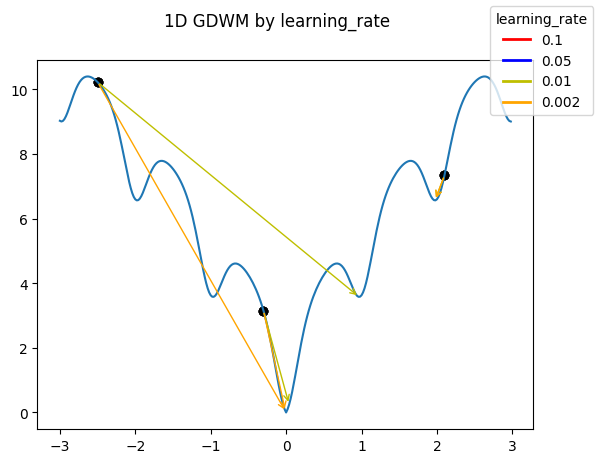

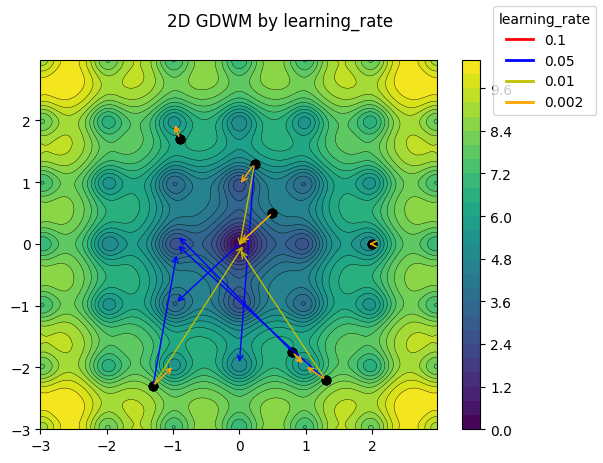

In [161]:
momentum_coefficient_multiple = 0.9

fig_1d_arrow_multiple_momentum = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple_momentum = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple_momentum = fig_1d_arrow_multiple_momentum.axes[0]
ax_2d_colours_arrow_multiple_momentum = fig_2d_colours_arrow_multiple_momentum.axes[0]

arrow_list_1d_multiple_momentum: list[Arrow] = []
arrow_list_1d_multiple_momentum_path: list[npt.NDArray[np.float64]] = []
arrow_list_2d_multiple_momentum: list[Arrow] = []
arrow_list_2d_multiple_momentum_path: list[npt.NDArray[np.float64]] = []
for learning_rate in learning_rate_multiple:
    for inp, outp in zip(inputs_1d_multiple, outputs_1d_multiple):
        after_descent_1d_single = gradient_descent_with_momentum(inp, learning_rate, momentum_coefficient_multiple, iterations_multiple, ackley_one_dim_grad, save_interval, min_grad_norm)
        # print(f"({inp[0]}, {outp}) -> ({after_descent_1d_single[0]}, {np.float64(ackley_one_dim(after_descent_1d_single[0]))}) @ {learning_rate}")
        arrow_list_1d_multiple_momentum.append(Arrow(
            inp[0],
            outp,
            after_descent_1d_single[0][0],
            np.float64(ackley_one_dim(after_descent_1d_single[0][0])),
            {
                "colour": learning_rate_colour_match[learning_rate],
                "learning_rate" : learning_rate
            }
        ))
        if learning_rate == np.min(learning_rate_multiple):
            arrow_list_1d_multiple_momentum_path.append(after_descent_1d_single[1])

    for inp in inputs_2d_multiple:
        after_descent_2d_single = gradient_descent_with_momentum(inp, learning_rate, momentum_coefficient_multiple, iterations_multiple, ackley_two_dim_grad, save_interval, min_grad_norm)
        arrow_list_2d_multiple_momentum.append(Arrow(
            inp[0],
            inp[1],
            after_descent_2d_single[0][0],
            after_descent_2d_single[0][1],
            {
                "colour": learning_rate_colour_match[learning_rate],
                "learning_rate" : learning_rate
            }
        ))
        if learning_rate == np.min(learning_rate_multiple):
            arrow_list_2d_multiple_momentum_path.append(after_descent_2d_single[1])

plot_gradient_descent(arrow_list_1d_multiple_momentum, ax_1d_arrow_multiple_momentum, fig_1d_arrow_multiple_momentum, "1D GDWM by learning_rate")
plot_gradient_descent(arrow_list_2d_multiple_momentum, ax_2d_colours_arrow_multiple_momentum, fig_2d_colours_arrow_multiple_momentum, "2D GDWM by learning_rate")

We can see that arrows with the higher learning_rates are often not even visible - they are too long to graph for us, which was usually not the case for regular GD. This means that higher learning_rate values behave even more unpredictably in Gradient Descent With Momentum than in basic Gradient Descent.
I would consider low learning_rates to be much more efficient for GDWM, especially for the 1D function. In 2D, a higher one can potentially be a little bit better, but it is unreliable and can cause extremely bad outcomes in the worst cases.

Finally, we can compare Gradient Descent to Gradient Descent With Momentum. For the comparison we will use the smallest learning_rate we have tested as both approaches performed well and reliably with this coefficient.

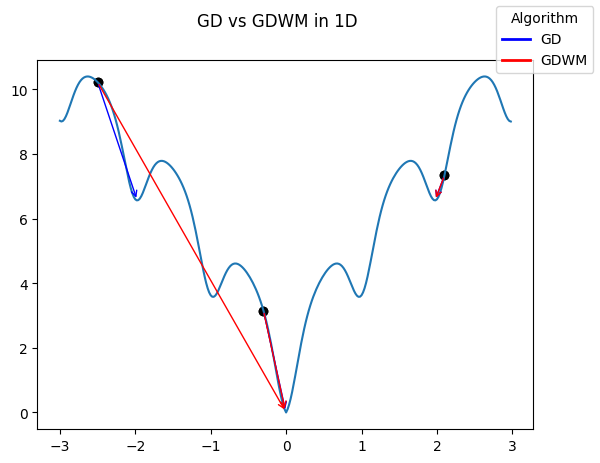

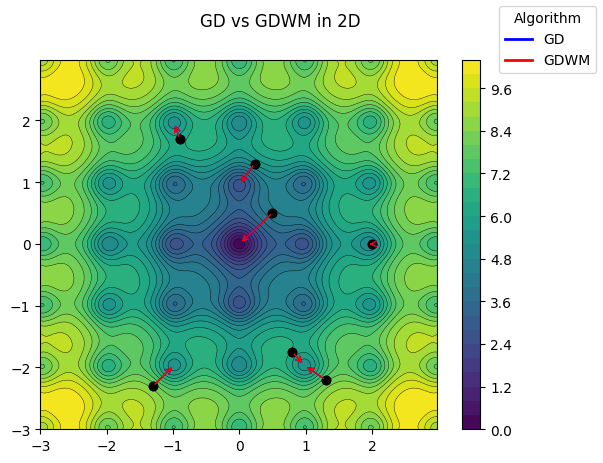

In [162]:
momentum_colour = "red"
regular_colour = "blue"

fig_1d_arrow_multiple_comparison = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple_comparison = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple_comparison = fig_1d_arrow_multiple_comparison.axes[0]
ax_2d_colours_arrow_multiple_comparison = fig_2d_colours_arrow_multiple_comparison.axes[0]

def has_smallest_learning_rate(arrow: Arrow) -> bool:
    return arrow.metadata["learning_rate"] == min(learning_rate_multiple)

def change_arrow_colour(arrow: Arrow, colour: str) -> Arrow:
    arrow.metadata["colour"] = colour
    return arrow

def filter_smallest_learning_rate(arrow_list: list[Arrow]) -> list[Arrow]:
    return list(filter(has_smallest_learning_rate, arrow_list))

arrow_list_1d_multiple_comparison = filter_smallest_learning_rate(arrow_list_1d_multiple)
arrow_list_1d_multiple_momentum_comparison = filter_smallest_learning_rate(arrow_list_1d_multiple_momentum)
arrow_list_2d_multiple_comparison = filter_smallest_learning_rate(arrow_list_2d_multiple)
arrow_list_2d_multiple_momentum_comparison = filter_smallest_learning_rate(arrow_list_2d_multiple_momentum)

arrow_list_1d_multiple_comparison = list(map(lambda x: change_arrow_colour(x, regular_colour), arrow_list_1d_multiple_comparison))
arrow_list_1d_multiple_momentum_comparison = list(map(lambda x: change_arrow_colour(x, momentum_colour), arrow_list_1d_multiple_momentum_comparison))
arrow_list_2d_multiple_comparison = list(map(lambda x: change_arrow_colour(x, regular_colour), arrow_list_2d_multiple_comparison))
arrow_list_2d_multiple_momentum_comparison = list(map(lambda x: change_arrow_colour(x, momentum_colour), arrow_list_2d_multiple_momentum_comparison))

# print(arrow_list_1d_multiple_comparison)
# print(arrow_list_1d_multiple_momentum_comparison)
# print(arrow_list_2d_multiple_comparison)
# print(arrow_list_2d_multiple_momentum_comparison)

annotate_arrows(arrow_list_1d_multiple_comparison, ax_1d_arrow_multiple_comparison)
annotate_arrows(arrow_list_1d_multiple_momentum_comparison, ax_1d_arrow_multiple_comparison)
sp = seperate_starting_points(arrow_list_1d_multiple_comparison)
ax_1d_arrow_multiple_comparison.scatter(*sp, c="black")
sp = seperate_starting_points(arrow_list_1d_multiple_momentum_comparison)
ax_1d_arrow_multiple_comparison.scatter(*sp, c="black")

legend_elements = [
    Line2D([0], [0], color=regular_colour, lw=2, label="GD"),
    Line2D([0], [0], color=momentum_colour, lw=2, label="GDWM"),
]
fig_1d_arrow_multiple_comparison.legend(handles=legend_elements, title="Algorithm")
fig_1d_arrow_multiple_comparison.suptitle("GD vs GDWM in 1D")
display(fig_1d_arrow_multiple_comparison)

annotate_arrows(arrow_list_2d_multiple_comparison, ax_2d_colours_arrow_multiple_comparison)
annotate_arrows(arrow_list_2d_multiple_momentum_comparison, ax_2d_colours_arrow_multiple_comparison)
sp = seperate_starting_points(arrow_list_2d_multiple_comparison)
ax_2d_colours_arrow_multiple_comparison.scatter(*sp, c="black")
sp = seperate_starting_points(arrow_list_2d_multiple_momentum_comparison)
ax_2d_colours_arrow_multiple_comparison.scatter(*sp, c="black")

# for elem in arrow_list_2d_multiple_momentum_path:
#     print("new")
#     print(elem.T)
#     ax_2d_colours_arrow_multiple_comparison.plot(*elem.T, color="red")

fig_2d_colours_arrow_multiple_comparison.legend(handles=legend_elements, title="Algorithm")
fig_2d_colours_arrow_multiple_comparison.suptitle("GD vs GDWM in 2D")
display(fig_2d_colours_arrow_multiple_comparison)


The results differ depending on the dimensionality of the function analyzed.

For 1D, there are some cases, where Gradient Descent With Momentum does go towards the global maximum even despite starting far away from it

In the case of the 2D function - the result did not really improve. In all the cases we can observe here, the blue and the red arrows overlap (they ended up in the same place).

As we can observe, GDWM can be an improvement compared to basic GD. It did go over a few local minimums to reach a better outcome. On the other hand, regular Gradient Descent tends to go towards the closest local minimum in almost all cases. This advantage seems to be much more prominent in 1D version. Gradient Descent With Momentum can definitely be considered superior in our case, as, on average, it provides more optimal results.